# Fine-tuning BERTurk for Turkish Emotion Classification

Fine-tunes `dbmdz/bert-base-turkish-cased` for multi-class emotion classification. Pipeline: text cleaning → stratified train/val/test split → class-weighted fine-tuning → evaluation on a held-out test set → inference.

## Setup

Add the project root to the path, fix the random seed for reproducibility, and import dependencies.

In [ ]:
import nltk
import torch
import pandas as pd

from nltk.corpus import stopwords
from huggingface_hub import notebook_login
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, EarlyStoppingCallback, DataCollatorWithPadding, set_seed

set_seed(42)
nltk.download("stopwords")
notebook_login()

In [ ]:
from src.data_process import make_dataset
from src.trainer import WeightedTrainer, compute_class_weights
from src.visualization import plot_confusion_matrix, plot_roc_auc
from src.evaluation import classification_report_fn, predict, compute_metrics

## Configuration

Model, paths, and training hyperparameters. `DEVICE` automatically selects CUDA, then Apple MPS, then CPU.

In [ ]:
BERT_MODEL_NAME = "dbmdz/bert-base-turkish-cased"
HF_REPO_ID      = "username/turkish-emotion-classifier"
DATA_PATH       = "data/turkish_emotion_manual_base_dataset.csv"

MAX_LENGTH = 32
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR         = 2e-5
SAVE_DIR   = "./turkish-emotion-classifier"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps"  if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## Data preparation

Load the dataset, clean the text, and drop very short samples. The split is stratified so the class balance is preserved across train/val/test. The `LabelEncoder` is fit on the training set only, to avoid leaking information from validation and test.

In [ ]:
df = pd.read_csv(DATA_PATH)

df = df.dropna(subset=["text", "label"])
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() > 0].reset_index(drop=True)

df = df.reset_index(drop=True)
df_train, df_temp = train_test_split(df, test_size=0.3, random_state=42, stratify=df["label"])
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp["label"])

In [8]:
label_encoder = LabelEncoder()
df_train["label"] = label_encoder.fit_transform(df_train["label"])
df_val["label"]   = label_encoder.transform(df_val["label"])
df_test["label"]  = label_encoder.transform(df_test["label"])

num_classes = len(label_encoder.classes_)
id2label    = {int(i): str(l) for i, l in enumerate(label_encoder.classes_)}
label2id    = {str(l): int(i) for i, l in enumerate(label_encoder.classes_)}

In [9]:
print(f"Num Classes      : {num_classes}")
print(f"Classes           : {list(id2label.values())}")
print(f"Train / Val / Test : {len(df_train)} / {len(df_val)} / {len(df_test)}")

Num Classes      : 6
Classes           : ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
Train / Val / Test : 16422 / 3519 / 3520


## Tokenization and model

Load the tokenizer, build the tokenized datasets, and instantiate the classification model. `DataCollatorWithPadding` pads each batch dynamically to the longest sequence in that batch.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer)

train_dataset, val_dataset, test_dataset = (make_dataset(df, tokenizer, MAX_LENGTH) for df in (df_train, df_val, df_test))
model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=num_classes, id2label=id2label, label2id=label2id).to(DEVICE)

## Training

`WeightedTrainer` applies class weights to the loss to counter class imbalance. The best checkpoint is selected on the validation `f1_macro`, and early stopping halts training once it stops improving.

In [11]:
training_args = TrainingArguments(
    output_dir=SAVE_DIR, # Modelin kaydedileceği klasör
    num_train_epochs=NUM_EPOCHS, # Tüm veriyi kaç kez görecek (3 = veriyi 3 kez baştan sona eğitir)
    per_device_train_batch_size=BATCH_SIZE, # Eğitimde her adımda kaç örnek beslenecek (32 = 32 metin aynı anda)
    per_device_eval_batch_size=BATCH_SIZE * 2, # Değerlendirmede kaç örnek aynı anda (eğitimden büyük olabilir, gradient hesaplanmıyor)
    learning_rate=LR, # Her adımda ağırlıkları ne kadar güncelleyecek (çok büyük → kayar, çok küçük → yavaş öğrenir)
    weight_decay=0.01, # Modelin aşırı öğrenmesini (overfitting) önlemek için ağırlıkları küçük tutar
    warmup_ratio=0.1, # Eğitimin ilk %10'unda learning rate'i yavaşça artırır, direkt tam hızla başlamaz
    fp16=torch.cuda.is_available(), # GPU varsa 16-bit hassasiyetle çalışır → daha hızlı, daha az bellek (CPU/MPS'de kapalı)
    eval_strategy="epoch", # Her epoch sonunda test verisinde değerlendirme yapar
    save_strategy="epoch", # Her epoch sonunda modeli diske kaydeder
    load_best_model_at_end=True, # Eğitim bitince en iyi sonucu veren epoch'un modelini yükler
    metric_for_best_model="f1_macro", # "En iyi model" hangisi? → accuracy'si en yüksek olan
    greater_is_better=True, # Metrik için büyük mü iyi? accuracy için True, loss için False olurdu
    save_total_limit=2, # Diskte en fazla 2 checkpoint tutar, eskiyi siler (yer kazanır)
    logging_steps=50, # Her 50 adımda bir loss, learning rate gibi değerleri loglar
    dataloader_num_workers=2, # Veriyi GPU'ya beslerken kaç paralel işlemci kullansın
    report_to="none", # Eğitim loglarını nereye göndersin? "none" = hiçbir yere (wandb, tensorboard gibi araçlar kapalı)
    push_to_hub=True,
    hub_model_id=HF_REPO_ID
    )

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [12]:
class_weights = compute_class_weights(df_train["label"].values, num_classes, DEVICE)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.186612,0.185824,0.946007,0.945987,0.948083,0.944227
2,0.141152,0.143561,0.959079,0.958254,0.957521,0.959223
3,0.076629,0.163876,0.961921,0.961745,0.962123,0.961923
4,0.036373,0.174940,0.962205,0.961604,0.962681,0.960791
5,0.026921,0.189188,0.963058,0.961983,0.960921,0.963491
6,0.013176,0.190143,0.965615,0.964978,0.965221,0.964895
7,0.014128,0.198018,0.964194,0.963511,0.964770,0.962455
8,0.001137,0.198963,0.967604,0.967254,0.967037,0.967591
9,0.006273,0.203600,0.966468,0.965745,0.966054,0.965577
10,0.004311,0.202156,0.967036,0.966395,0.966667,0.966227


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5140, training_loss=0.12574365238155372, metrics={'train_runtime': 665.3568, 'train_samples_per_second': 246.815, 'train_steps_per_second': 7.725, 'total_flos': 2254523378105664.0, 'train_loss': 0.12574365238155372, 'epoch': 10.0})

## Evaluation on the held-out test set

Run the best model on the test set — untouched during training and model selection — and report the classification metrics, confusion matrix, and ROC curves.

              precision    recall  f1-score   support

       anger       0.96      0.96      0.96       616
     disgust       0.96      0.98      0.97       419
        fear       0.98      0.97      0.97       623
         joy       0.98      0.98      0.98       783
     sadness       0.96      0.97      0.96       662
    surprise       0.96      0.96      0.96       417

    accuracy                           0.97      3520
   macro avg       0.97      0.97      0.97      3520
weighted avg       0.97      0.97      0.97      3520



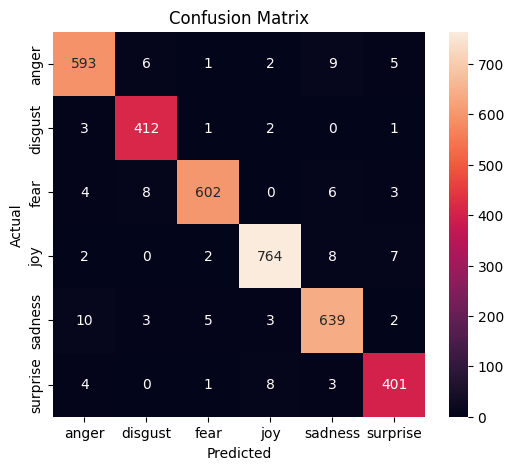

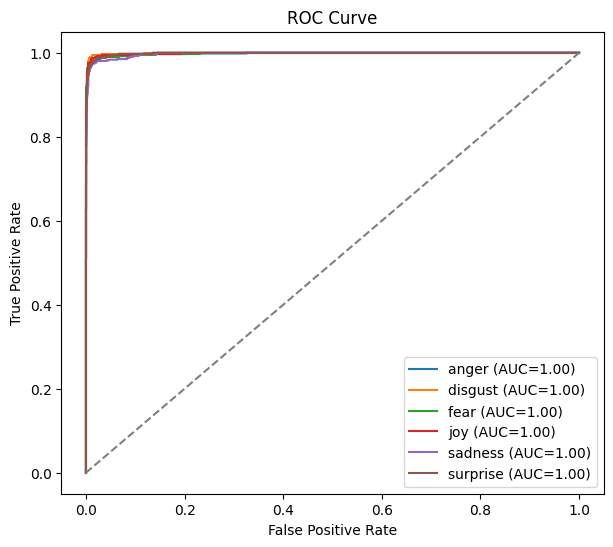

In [13]:
pred   = trainer.predict(test_dataset)
y_true = pred.label_ids
y_probs = torch.softmax(torch.tensor(pred.predictions), dim=1).numpy()
y_pred  = y_probs.argmax(axis=1)

print(classification_report_fn(y_true, y_pred, label_encoder))
plot_confusion_matrix(y_true, y_pred, label_encoder)
plot_roc_auc(y_true, y_probs, label_encoder)

## Save the model

Persist the fine-tuned model and tokenizer to disk for later reuse.

In [ ]:
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

trainer.push_to_hub(commit_message="Initial model upload")
tokenizer.push_to_hub(HF_REPO_ID, commit_message="Initial tokenizer upload")